In [1]:
import pandas as pd
df1 = pd.read_csv("COMBINED_DATA_2025.csv", low_memory=False)
df2 = pd.read_csv("COMBINED_DATA_2024.csv", low_memory=False)

df = pd.concat([df1, df2])

In [2]:
columns_needed = [
    "VAERS_ID",
    "AGE_YRS",
    "SEX",
    "DIED",
    "OTHER_MEDS",
    "ALLERGIES",
    "SYMPTOM1",
    "SYMPTOM2",
    "SYMPTOM3",
    "SYMPTOM4",
    "SYMPTOM5",
    "DATEDIED",
    "VAX_DATE",
    "L_THREAT",
    "ER_VISIT",
    "VAX_TYPE"
]

df = df[columns_needed]

In [3]:
df = df[df["VAX_TYPE"] == "COVID19"]

In [4]:
df = df.drop_duplicates()

In [5]:
df = df.drop_duplicates(subset=["VAERS_ID"])

In [6]:
df = df[df["AGE_YRS"] >= 18]

In [7]:
df["VAX_DATE"] = pd.to_datetime(df["VAX_DATE"], errors="coerce")
df["DATEDIED"] = pd.to_datetime(df["DATEDIED"], errors="coerce")

In [8]:
df["SERIOUS_EVENT"] = (
    (df["DIED"] == "Y") |
    (df["L_THREAT"] == "Y") |
    (df["ER_VISIT"] == "Y")
).astype(int)

In [9]:
df["SERIOUS_EVENT"].value_counts()

SERIOUS_EVENT
0    14216
1     1253
Name: count, dtype: int64

In [10]:
df[["DIED","L_THREAT","ER_VISIT","SERIOUS_EVENT"]].head()

,DIED,L_THREAT,ER_VISIT,SERIOUS_EVENT
1,NaN,NaN,NaN,0
11,NaN,NaN,NaN,0
52,NaN,NaN,NaN,0
62,NaN,NaN,NaN,0
74,NaN,NaN,NaN,0


In [11]:
df[["DIED","L_THREAT","ER_VISIT"]] = df[["DIED","L_THREAT","ER_VISIT"]].fillna("N")

In [12]:
df["AGE_YRS"].describe()

count    15469.000000
mean        59.518456
std         18.024898
min         18.000000
25%         46.000000
50%         63.000000
75%         73.000000
max        106.000000
Name: AGE_YRS, dtype: float64

In [13]:
df = df[(df["AGE_YRS"] >= 18) & (df["AGE_YRS"] <= 100)]

In [14]:
df = df[df["SEX"].isin(["M","F"])]

In [15]:
symptom_cols = ["SYMPTOM1","SYMPTOM2","SYMPTOM3","SYMPTOM4","SYMPTOM5"]

for col in symptom_cols:
    df[col] = df[col].str.upper()

In [16]:
df["AGE_GROUP"] = pd.cut(
    df["AGE_YRS"],
    bins=[18,30,40,50,60,70,80,100],
    labels=["18-30","31-40","41-50","51-60","61-70","71-80","80+"]
)

In [17]:
df["SERIOUS_EVENT"].value_counts(normalize=True)

SERIOUS_EVENT
0    0.918836
1    0.081164
Name: proportion, dtype: float64

In [18]:
df.shape

(15364, 18)

In [ ]:
Combine All Symptom Columns First

In [19]:
symptom_cols = ["SYMPTOM1","SYMPTOM2","SYMPTOM3","SYMPTOM4","SYMPTOM5"]

df["ALL_SYMPTOMS"] = df[symptom_cols].apply(
    lambda x: ", ".join(x.dropna().astype(str)), axis=1
)

Create Binary Symptom Features

Find the most common symptoms

In [20]:
from collections import Counter

all_symptoms = []

for col in symptom_cols:
    all_symptoms.extend(df[col].dropna().str.lower())

symptom_counts = Counter(all_symptoms)

top_symptoms = [symptom for symptom, count in symptom_counts.most_common(50)]

Create features

In [21]:
for symptom in top_symptoms:
    df[symptom] = df["ALL_SYMPTOMS"].str.contains(symptom, case=False).astype(int)

In [22]:
df.head()

,VAERS_ID,AGE_YRS,SEX,DIED,OTHER_MEDS,ALLERGIES,SYMPTOM1,SYMPTOM2,SYMPTOM3,SYMPTOM4,...,tinnitus,laboratory test,syncope,mobility decreased,atrial fibrillation,peripheral swelling,sars-cov-2 test positive,urticaria,product administered to patient of inappropriate age,computerised tomogram
1,2818783,57.0,F,N,"Lisinopril, omeprazole, naproxen, levocetirizi...",percocet,MUSCULAR WEAKNESS,PAIN,PAIN IN EXTREMITY,TENDERNESS,...,0,0,0,0,0,0,0,0,0,0
11,2818873,44.0,F,N,NaN,NaN,BLISTER,RASH,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
52,2818917,58.0,M,N,"fish oil 1000 mg twice daily, vitamin d2 50 mc...",-no known allergies,BURNING SENSATION,INJECTION SITE BRUISING,INJECTION SITE PAIN,NEEDLE ISSUE,...,0,0,0,0,0,0,0,0,0,0
62,2818921,57.0,F,N,"Synthroid, estrogen patch, progesterone, ezeti...","penicillin, sulfa",ACOUSTIC STIMULATION TESTS ABNORMAL,BLOOD TEST NORMAL,CEREBROVASCULAR ACCIDENT,COMPUTERISED TOMOGRAM HEART NORMAL,...,0,0,0,0,0,0,0,0,0,1
74,2818924,61.0,M,N,"Lisinoril, Atorvastatin",NaN,BELL'S PALSY,BORRELIA TEST NEGATIVE,FACIAL PARALYSIS,NaN,...,0,0,0,0,0,0,0,0,0,0


In [23]:
df.isnull().sum()

VAERS_ID                                                   0
AGE_YRS                                                    0
SEX                                                        0
DIED                                                       0
OTHER_MEDS                                              8201
                                                        ... 
peripheral swelling                                        0
sars-cov-2 test positive                                   0
urticaria                                                  0
product administered to patient of inappropriate age       0
computerised tomogram                                      0
Length: 69, dtype: int64

In [24]:
(df.isnull().sum() / len(df)) * 100

VAERS_ID                                                 0.000000
AGE_YRS                                                  0.000000
SEX                                                      0.000000
DIED                                                     0.000000
OTHER_MEDS                                              53.378027
                                                          ...    
peripheral swelling                                      0.000000
sars-cov-2 test positive                                 0.000000
urticaria                                                0.000000
product administered to patient of inappropriate age     0.000000
computerised tomogram                                    0.000000
Length: 69, dtype: float64

In [25]:
df.isnull().sum()[df.isnull().sum() > 0]

OTHER_MEDS     8201
ALLERGIES      9104
SYMPTOM2       3731
SYMPTOM3       7057
SYMPTOM4       9302
SYMPTOM5      10752
DATEDIED      14725
VAX_DATE        320
AGE_GROUP        93
dtype: int64

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df.shape

(15364, 69)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15364 entries, 1 to 95863
Data columns (total 69 columns):
 #   Column                                                Non-Null Count  Dtype         
---  ------                                                --------------  -----         
 0   VAERS_ID                                              15364 non-null  int64         
 1   AGE_YRS                                               15364 non-null  float64       
 2   SEX                                                   15364 non-null  object        
 3   DIED                                                  15364 non-null  object        
 4   OTHER_MEDS                                            7163 non-null   object        
 5   ALLERGIES                                             6260 non-null   object        
 6   SYMPTOM1                                              15364 non-null  object        
 7   SYMPTOM2                                              11633 non-null  object     

In [29]:
df.describe()

,VAERS_ID,AGE_YRS,DATEDIED,VAX_DATE,SERIOUS_EVENT,covid-19,fatigue,expired product administered,headache,no adverse event,...,tinnitus,laboratory test,syncope,mobility decreased,atrial fibrillation,peripheral swelling,sars-cov-2 test positive,urticaria,product administered to patient of inappropriate age,computerised tomogram
count,1.536400e+04,15364.000000,639,15044,15364.000000,15364.000000,15364.000000,15364.000000,15364.000000,15364.000000,...,15364.000000,15364.000000,15364.000000,15364.000000,15364.000000,15364.000000,15364.000000,15364.000000,15364.000000,15364.000000
mean,2.782813e+06,59.508592,2023-11-08 23:46:28.732394240,2023-08-05 18:40:23.610741504,0.081164,0.153085,0.069969,0.061638,0.056300,0.055454,...,0.014840,0.018290,0.015426,0.021479,0.014319,0.013994,0.013733,0.016662,0.013083,0.030982
min,1.115875e+06,18.000000,2021-01-10 00:00:00,1923-12-19 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.755120e+06,46.000000,2023-03-05 00:00:00,2022-01-31 18:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.792692e+06,63.000000,2023-12-25 00:00:00,2024-01-22 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.810488e+06,73.000000,2024-10-15 00:00:00,2024-10-03 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2.851093e+06,100.000000,2025-07-18 00:00:00,2025-07-14 00:00:00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
std,6.447339e+04,18.001312,NaN,NaN,0.273095,0.360081,0.255103,0.240504,0.230508,0.228872,...,0.120916,0.134001,0.123242,0.144979,0.118807,0.117468,0.116386,0.128007,0.113632,0.173273


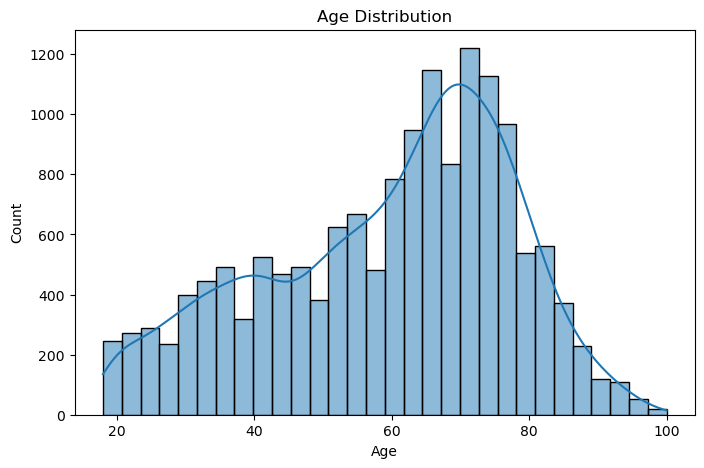

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(df["AGE_YRS"], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

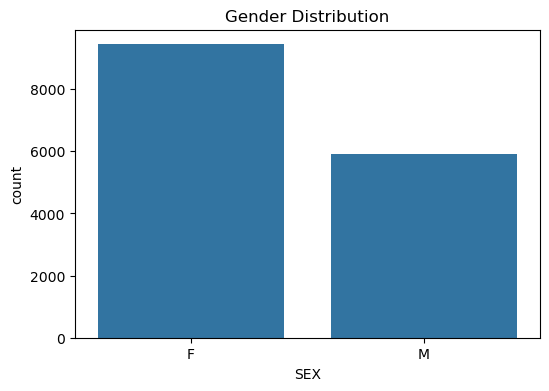

In [31]:
plt.figure(figsize=(6,4))
sns.countplot(x="SEX", data=df)
plt.title("Gender Distribution")
plt.show()

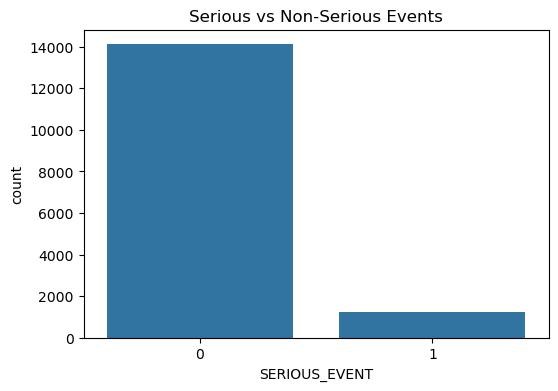

In [32]:
plt.figure(figsize=(6,4))
sns.countplot(x="SERIOUS_EVENT", data=df)
plt.title("Serious vs Non-Serious Events")
plt.show()

In [33]:
df["SERIOUS_EVENT"].value_counts(normalize=True)

SERIOUS_EVENT
0    0.918836
1    0.081164
Name: proportion, dtype: float64

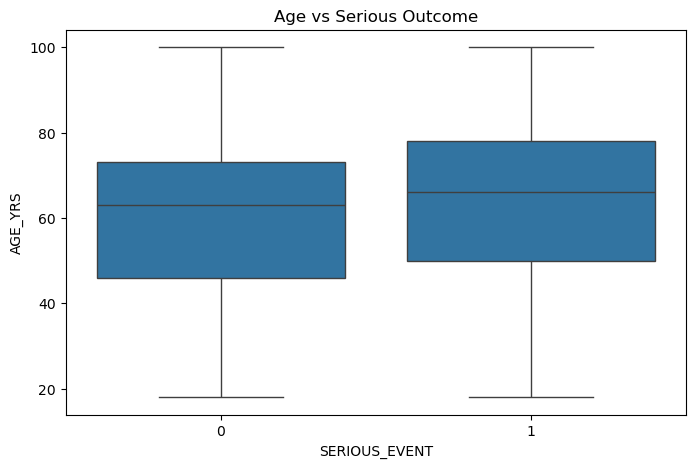

In [34]:
plt.figure(figsize=(8,5))
sns.boxplot(x="SERIOUS_EVENT", y="AGE_YRS", data=df)
plt.title("Age vs Serious Outcome")
plt.show()

In [35]:
symptom_cols = top_symptoms

In [36]:
symptom_counts = df[symptom_cols].sum().sort_values(ascending=False)

symptom_counts.head(20)

pain                            2898
covid-19                        2352
fatigue                         1075
erythema                        1051
expired product administered     947
headache                         865
dizziness                        859
no adverse event                 852
sars-cov-2 test                  846
chills                           788
arthralgia                       740
injection site pain              720
asthenia                         719
vaccination failure              691
pain in extremity                643
rash                             616
pruritus                         587
injection site erythema          575
dyspnoea                         564
drug ineffective                 563
dtype: int64

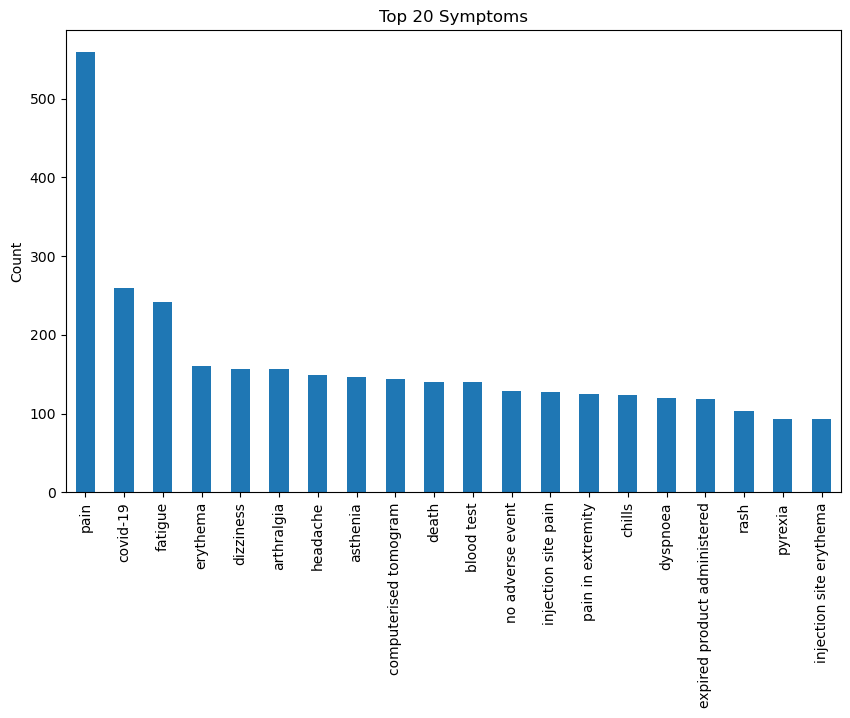

In [41]:
plt.figure(figsize=(10,6))
symptom_counts.head(20).plot(kind="bar")
plt.title("Top 20 Symptoms")
plt.ylabel("Count")
plt.show()

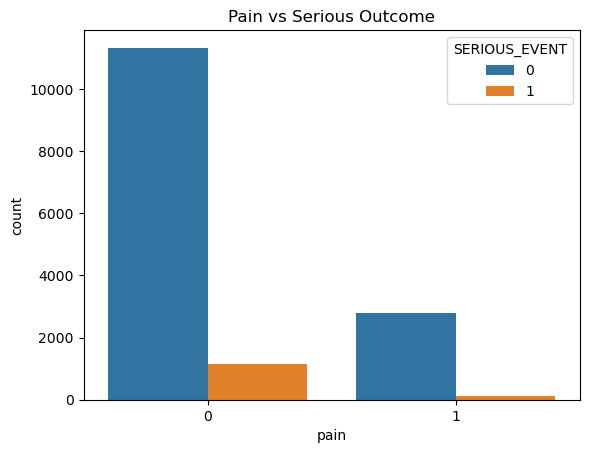

In [37]:
sns.countplot(x="pain", hue="SERIOUS_EVENT", data=df)
plt.title("Pain vs Serious Outcome")
plt.show()

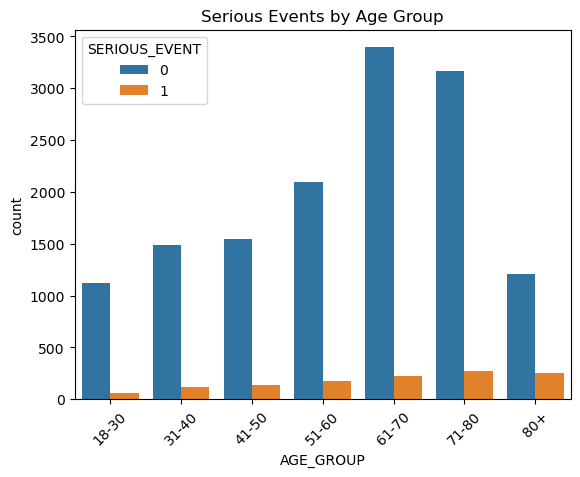

In [40]:
df = df.reset_index(drop=True)
sns.countplot(x="AGE_GROUP", hue="SERIOUS_EVENT", data=df)
plt.xticks(rotation=45)
plt.title("Serious Events by Age Group")
plt.show()

In [41]:
df.head(5)

,VAERS_ID,AGE_YRS,SEX,DIED,OTHER_MEDS,ALLERGIES,SYMPTOM1,SYMPTOM2,SYMPTOM3,SYMPTOM4,...,tinnitus,laboratory test,syncope,mobility decreased,atrial fibrillation,peripheral swelling,sars-cov-2 test positive,urticaria,product administered to patient of inappropriate age,computerised tomogram
0,2818783,57.0,F,N,"Lisinopril, omeprazole, naproxen, levocetirizi...",percocet,MUSCULAR WEAKNESS,PAIN,PAIN IN EXTREMITY,TENDERNESS,...,0,0,0,0,0,0,0,0,0,0
1,2818873,44.0,F,N,NaN,NaN,BLISTER,RASH,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
2,2818917,58.0,M,N,"fish oil 1000 mg twice daily, vitamin d2 50 mc...",-no known allergies,BURNING SENSATION,INJECTION SITE BRUISING,INJECTION SITE PAIN,NEEDLE ISSUE,...,0,0,0,0,0,0,0,0,0,0
3,2818921,57.0,F,N,"Synthroid, estrogen patch, progesterone, ezeti...","penicillin, sulfa",ACOUSTIC STIMULATION TESTS ABNORMAL,BLOOD TEST NORMAL,CEREBROVASCULAR ACCIDENT,COMPUTERISED TOMOGRAM HEART NORMAL,...,0,0,0,0,0,0,0,0,0,1
4,2818924,61.0,M,N,"Lisinoril, Atorvastatin",NaN,BELL'S PALSY,BORRELIA TEST NEGATIVE,FACIAL PARALYSIS,NaN,...,0,0,0,0,0,0,0,0,0,0


In [42]:
df.to_csv("clean_vaers_data.csv", index=False)

In [67]:
drop_cols = [
"VAERS_ID","OTHER_MEDS","ALLERGIES","AGE_YRS",
"SYMPTOM1","SYMPTOM2","SYMPTOM3","SYMPTOM4","SYMPTOM5",
"ALL_SYMPTOMS","VAX_DATE","DATEDIED","VAX_TYPE","AGE_GROUP","DIED", "L_THREAT", "ER_VISIT"
]

df_model = df.drop(columns=drop_cols)

In [68]:
df_model["SEX"] = df_model["SEX"].map({"M":1,"F":0})

In [69]:
X = df_model.drop(columns=["SERIOUS_EVENT"])
y = df_model["SERIOUS_EVENT"]

In [70]:
X = X.fillna(0)

In [71]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2,
random_state=42
)

In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15364 entries, 0 to 15363
Data columns (total 69 columns):
 #   Column                                                Non-Null Count  Dtype         
---  ------                                                --------------  -----         
 0   VAERS_ID                                              15364 non-null  int64         
 1   AGE_YRS                                               15364 non-null  float64       
 2   SEX                                                   15364 non-null  object        
 3   DIED                                                  15364 non-null  object        
 4   OTHER_MEDS                                            7163 non-null   object        
 5   ALLERGIES                                             6260 non-null   object        
 6   SYMPTOM1                                              15364 non-null  object        
 7   SYMPTOM2                                              11633 non-null  object

In [74]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

pred = log_model.predict(X_test_scaled)

In [75]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, pred))

print(confusion_matrix(y_test, pred))

print(classification_report(y_test, pred))

Accuracy: 0.9521640091116174
[[2818    7]
 [ 140  108]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      2825
           1       0.94      0.44      0.60       248

    accuracy                           0.95      3073
   macro avg       0.95      0.72      0.78      3073
weighted avg       0.95      0.95      0.94      3073



In [76]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [77]:
print("Accuracy:", accuracy_score(y_test, rf_pred))

Accuracy: 0.9505369345916043


In [78]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)

importance.sort_values(ascending=False).head(15)

death                    0.488114
breakthrough covid-19    0.154011
computerised tomogram    0.023263
SEX                      0.022697
asthenia                 0.018512
sars-cov-2 test          0.015215
atrial fibrillation      0.014344
fatigue                  0.014079
blood test               0.014043
dyspnoea                 0.013792
electrocardiogram        0.013269
covid-19                 0.012924
laboratory test          0.012738
pain                     0.012638
dizziness                0.012329
dtype: float64

<Axes: >

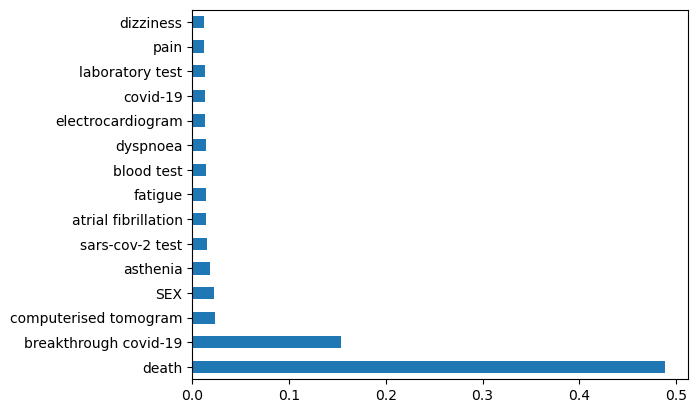

In [79]:
importance.sort_values(ascending=False).head(15).plot(kind="barh")

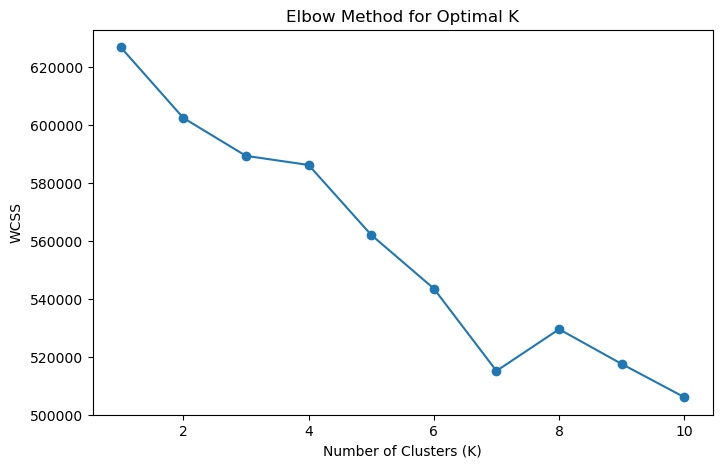

In [80]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()

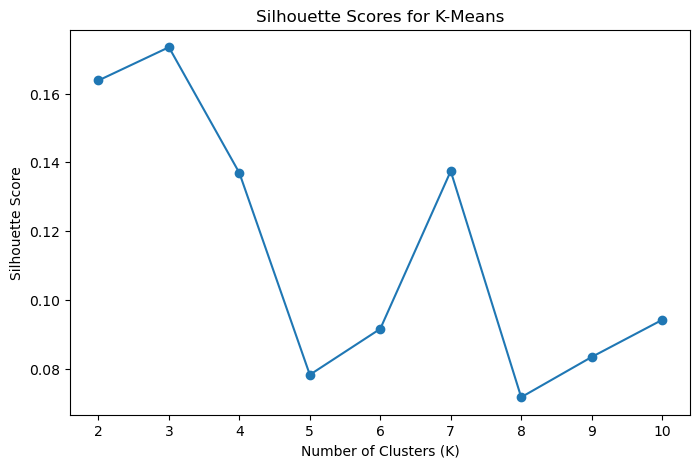

In [81]:
from sklearn.metrics import silhouette_score

sil_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_train_scaled)
    score = silhouette_score(X_train_scaled, labels)
    sil_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(K_range, sil_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for K-Means")
plt.show()

In [82]:
kmeans = KMeans(n_clusters=3, random_state=42)

train_clusters = kmeans.fit_predict(X_train_scaled)
test_clusters = kmeans.predict(X_test_scaled)

In [83]:
import numpy as np

X_train_cluster = np.column_stack((X_train_scaled, train_clusters))
X_test_cluster = np.column_stack((X_test_scaled, test_clusters))

In [84]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf')

svm_model.fit(X_train_cluster, y_train)

SVC()

In [85]:
y_pred = svm_model.predict(X_test_cluster)

In [86]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9521640091116174

Confusion Matrix:
[[2823    2]
 [ 145  103]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      2825
           1       0.98      0.42      0.58       248

    accuracy                           0.95      3073
   macro avg       0.97      0.71      0.78      3073
weighted avg       0.95      0.95      0.94      3073



In [87]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

In [88]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, xgb_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

Accuracy: 0.9534656687276277

Confusion Matrix:
[[2822    3]
 [ 140  108]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      2825
           1       0.97      0.44      0.60       248

    accuracy                           0.95      3073
   macro avg       0.96      0.72      0.79      3073
weighted avg       0.95      0.95      0.95      3073

